# 🌊 Coastal Assessment using Sentinel-2 Satellite Images + 1D CNN

## Project Goal
Analyze satellite images to determine if a coastal area is being damaged (e.g., seagrass loss, shoreline erosion), and provide evidence-based advice for government agencies.

## Data Source
- **Copernicus Sentinel-2** satellite images (multi-spectral bands: B02, B03, B04, B08)
- TIFF 32-bit float format
- Focus areas: High-change coastal zones (e.g., Manila Bay, Boracay, Siargao)

## Workflow
1. Load satellite bands from TIFF files
2. Calculate NDVI (Normalized Difference Vegetation Index)
3. Automated pixel classification (Seagrass, Water, Sand)
4. Export training data to CSV
5. Build and train 1D CNN model
6. Predict on new images
7. Visualize results
8. Calculate area changes (km²)

## Step 0: Setup and Install Dependencies

Install all required libraries for satellite image processing and machine learning.

In [13]:
# Install required packages (uncomment if needed)
# !pip install numpy pandas matplotlib rasterio scikit-learn tensorflow jupyter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## Step 1: Load Sentinel-2 Satellite Bands

Load multi-spectral bands from TIFF files:
- **B02**: Blue (490 nm)
- **B03**: Green (560 nm)
- **B04**: Red (665 nm)
- **B08**: Near-Infrared / NIR (842 nm)

Image dimensions: (424, 480)
B02 (Blue) - Min: 0.0047, Max: 0.5747
B03 (Green) - Min: 0.0073, Max: 0.6626
B04 (Red) - Min: 0.0016, Max: 0.6380
B08 (NIR) - Min: 0.0000, Max: 0.6969


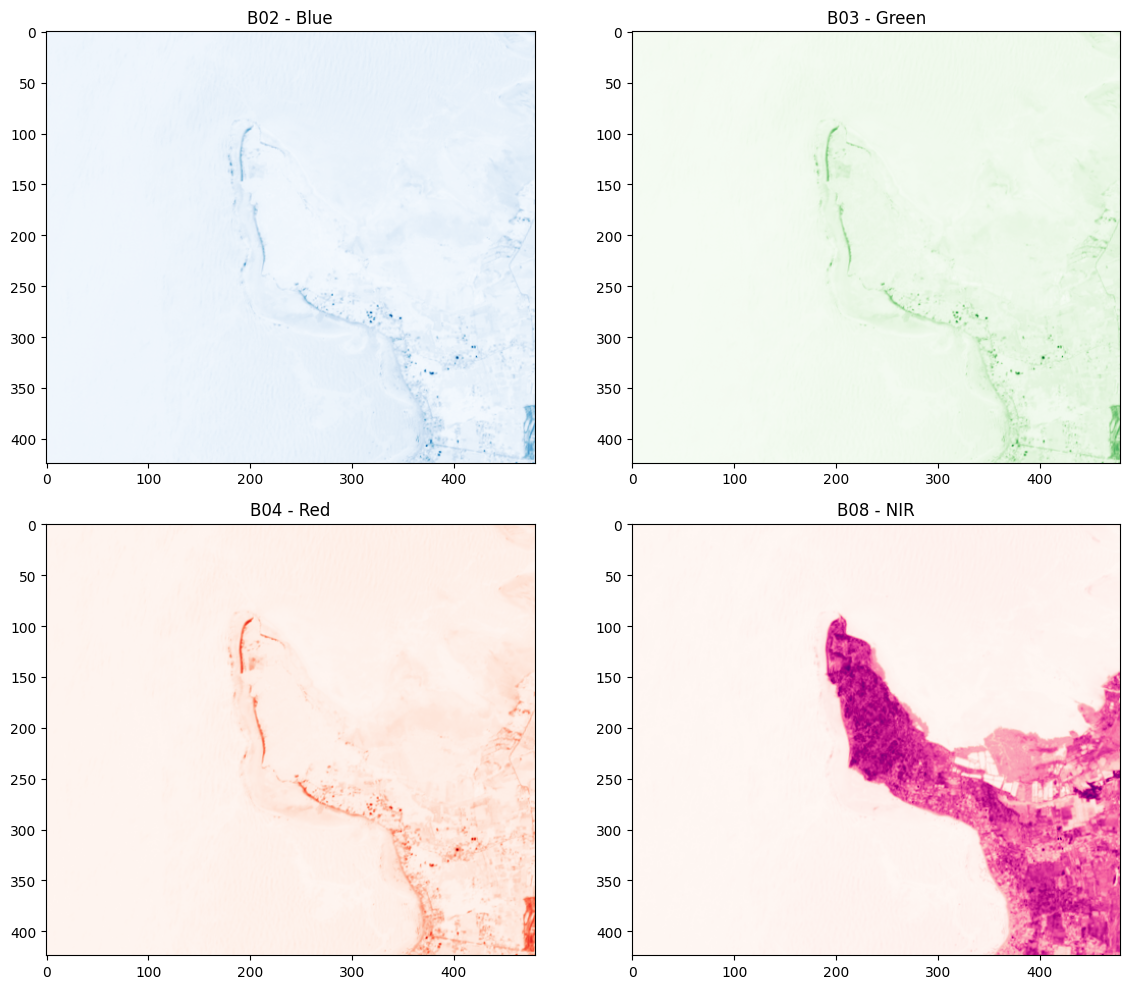

In [14]:
# Load Sentinel-2 bands from TIFF files
# Update paths to match your file locations

B02 = rasterio.open("coastalImage/B02.tiff").read(1).astype(float)  # Blue
B03 = rasterio.open("coastalImage/B03.tiff").read(1).astype(float)  # Green
B04 = rasterio.open("coastalImage/B04.tiff").read(1).astype(float)  # Red
B08 = rasterio.open("coastalImage/B08.tiff").read(1).astype(float)  # NIR

print(f"Image dimensions: {B02.shape}")
print(f"B02 (Blue) - Min: {B02.min():.4f}, Max: {B02.max():.4f}")
print(f"B03 (Green) - Min: {B03.min():.4f}, Max: {B03.max():.4f}")
print(f"B04 (Red) - Min: {B04.min():.4f}, Max: {B04.max():.4f}")
print(f"B08 (NIR) - Min: {B08.min():.4f}, Max: {B08.max():.4f}")

# Visualize the bands
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes[0, 0].imshow(B02, cmap='Blues')
axes[0, 0].set_title('B02 - Blue')
axes[0, 1].imshow(B03, cmap='Greens')
axes[0, 1].set_title('B03 - Green')
axes[1, 0].imshow(B04, cmap='Reds')
axes[1, 0].set_title('B04 - Red')
axes[1, 1].imshow(B08, cmap='RdPu')
axes[1, 1].set_title('B08 - NIR')
plt.tight_layout()
plt.show()

## Step 2: Calculate NDVI (Normalized Difference Vegetation Index)

NDVI formula: **NDVI = (NIR - Red) / (NIR + Red)**

- **NDVI > 0.3**: Healthy vegetation (seagrass)
- **0 ≤ NDVI ≤ 0.3**: Bare soil / sand
- **NDVI < 0**: Water bodies

NDVI - Min: -1.0000, Max: 0.9550, Mean: -0.0641


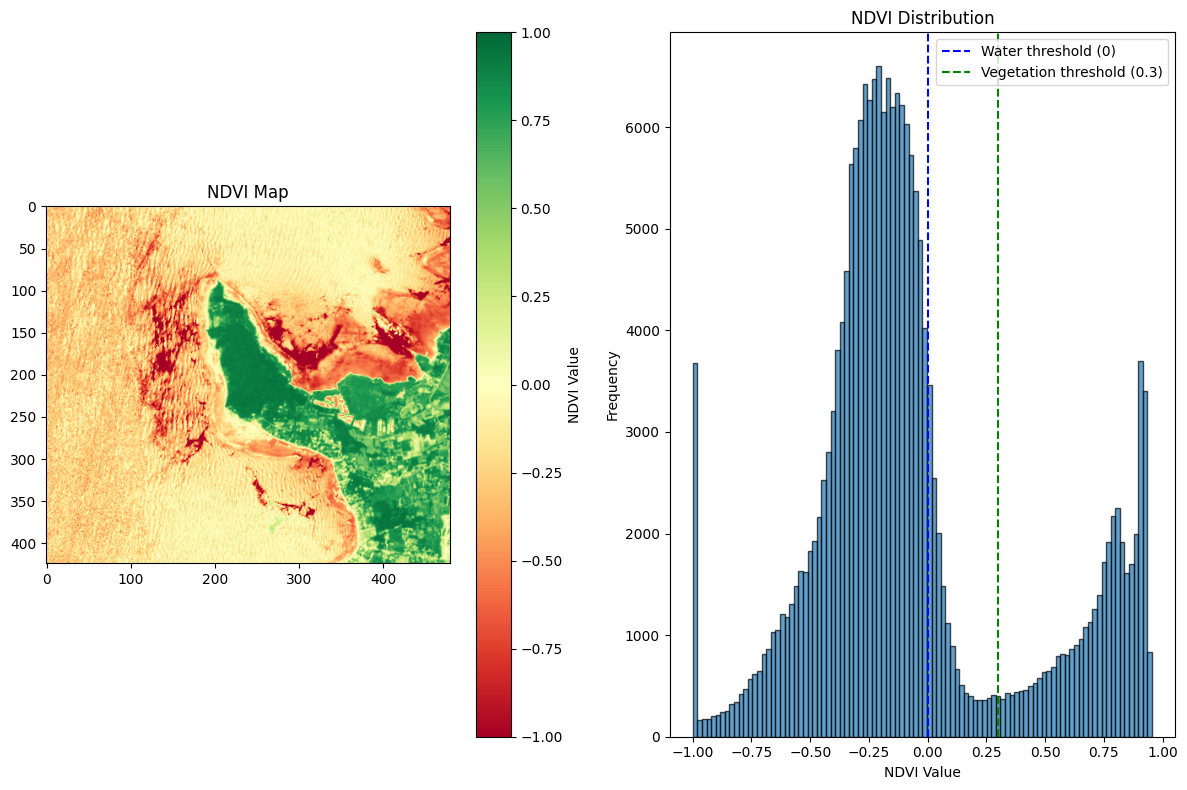

In [15]:
# Calculate NDVI
ndvi = (B08 - B04) / (B08 + B04 + 1e-10)  # Add small epsilon to avoid division by zero

print(f"NDVI - Min: {ndvi.min():.4f}, Max: {ndvi.max():.4f}, Mean: {ndvi.mean():.4f}")

# Visualize NDVI
plt.figure(figsize=(12, 8))
plt.subplot(1, 2, 1)
im = plt.imshow(ndvi, cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar(im, label='NDVI Value')
plt.title('NDVI Map')

plt.subplot(1, 2, 2)
plt.hist(ndvi.flatten(), bins=100, edgecolor='black', alpha=0.7)
plt.xlabel('NDVI Value')
plt.ylabel('Frequency')
plt.title('NDVI Distribution')
plt.axvline(x=0, color='blue', linestyle='--', label='Water threshold (0)')
plt.axvline(x=0.3, color='green', linestyle='--', label='Vegetation threshold (0.3)')
plt.legend()
plt.tight_layout()
plt.show()

## Step 3: Automated Pixel Classification (Ground Truth)

Apply NDVI thresholds to classify pixels into categories:
- **Label 0**: Cloud/No Data
- **Label 1**: Seagrass (NDVI > 0.3)
- **Label 2**: Water (NDVI < 0)
- **Label 3**: Sand/Bare Soil (0 ≤ NDVI ≤ 0.3)

Pixel Classification Summary:
  Seagrass: 39,596 pixels (19.46%)
  Water: 148,578 pixels (73.00%)
  Sand: 15,346 pixels (7.54%)


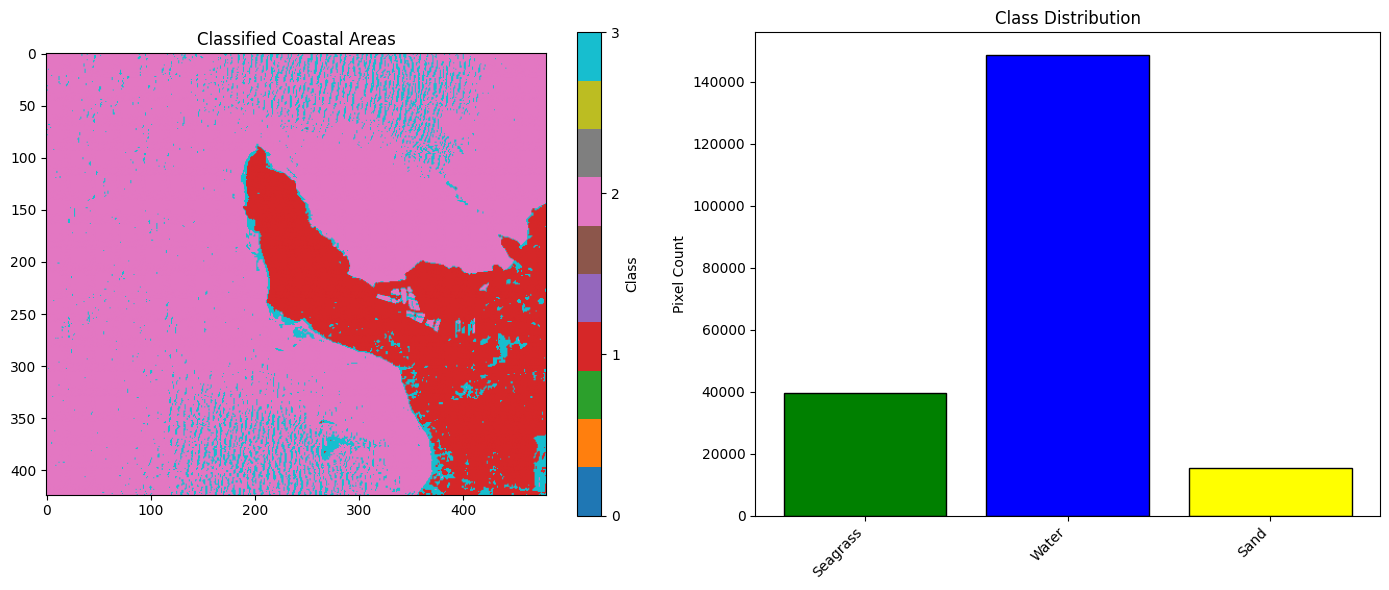

In [16]:
# Apply thresholding for automated classification
labels = np.zeros(ndvi.shape)
labels[ndvi > 0.3] = 1    # Seagrass (healthy vegetation)
labels[ndvi < 0] = 2      # Water
labels[(ndvi >= 0) & (ndvi <= 0.3)] = 3  # Sand/Bare Soil

# Count pixels in each class
unique, counts = np.unique(labels, return_counts=True)
class_names = {0: 'Cloud/No Data', 1: 'Seagrass', 2: 'Water', 3: 'Sand'}

print("Pixel Classification Summary:")
for label, count in zip(unique, counts):
    percentage = (count / labels.size) * 100
    print(f"  {class_names[label]}: {count:,} pixels ({percentage:.2f}%)")

# Visualize classified map
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
im = plt.imshow(labels, cmap='tab10', vmin=0, vmax=3)
plt.colorbar(im, ticks=[0, 1, 2, 3], label='Class')
plt.title('Classified Coastal Areas')

plt.subplot(1, 2, 2)
colors = ['gray', 'green', 'blue', 'yellow']
plt.bar([class_names[l] for l in unique], counts, color=[colors[int(l)] for l in unique], edgecolor='black')
plt.ylabel('Pixel Count')
plt.title('Class Distribution')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Step 4: Flatten and Export Training Data to CSV

Prepare data for 1D CNN training by:
1. Flattening 2D band arrays into 1D vectors
2. Stacking spectral bands with NDVI as features
3. Exporting to CSV with corresponding labels

In [17]:
# Flatten bands and NDVI into 1D vectors
data = np.stack([
    B02.flatten(), 
    B03.flatten(), 
    B04.flatten(), 
    B08.flatten(), 
    ndvi.flatten()
], axis=1)

labels_flat = labels.flatten()

# Create DataFrame
df = pd.DataFrame(data, columns=["B02", "B03", "B04", "B08", "NDVI"])
df["Label"] = labels_flat.astype(int)

# Display sample data
print("Training Data Sample:")
print(df.head(10))
print(f"\nDataset shape: {df.shape}")
print(f"Features: B02, B03, B04, B08, NDVI")
print(f"Target: Label (0=Cloud, 1=Seagrass, 2=Water, 3=Sand)")

# Export to CSV
df.to_csv("training_data.csv", index=False)
print("\n✅ Training data exported to 'training_data.csv'")

Training Data Sample:
      B02     B03     B04     B08      NDVI  Label
0  0.0331  0.0231  0.0101  0.0074 -0.154286      2
1  0.0347  0.0231  0.0088  0.0076 -0.073171      2
2  0.0341  0.0234  0.0085  0.0065 -0.133333      2
3  0.0321  0.0221  0.0077  0.0049 -0.222222      2
4  0.0321  0.0206  0.0068  0.0036 -0.307692      2
5  0.0312  0.0216  0.0067  0.0034 -0.326733      2
6  0.0306  0.0225  0.0061  0.0038 -0.232323      2
7  0.0307  0.0220  0.0061  0.0038 -0.232323      2
8  0.0305  0.0207  0.0067  0.0039 -0.264151      2
9  0.0310  0.0197  0.0057  0.0037 -0.212766      2

Dataset shape: (203520, 6)
Features: B02, B03, B04, B08, NDVI
Target: Label (0=Cloud, 1=Seagrass, 2=Water, 3=Sand)

✅ Training data exported to 'training_data.csv'


## Step 5: Build and Train 1D CNN Model

Create a 1D Convolutional Neural Network to classify coastal pixels:
- **Input**: 5 features (B02, B03, B04, B08, NDVI)
- **Architecture**: Conv1D → MaxPooling → Flatten → Dense layers
- **Output**: 4 classes (Cloud, Seagrass, Water, Sand)

In [18]:
import tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Dense, Flatten, MaxPooling1D, Dropout
from tensorflow.keras.utils import to_categorical

# Prepare data for CNN
X = df[["B02", "B03", "B04", "B08", "NDVI"]].values
y = df["Label"].values

# Reshape X for 1D CNN (samples, features, channels)
X = X.reshape(-1, 5, 1)

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# Build 1D CNN model
model = Sequential([
    Conv1D(32, kernel_size=2, activation='relu', input_shape=(5, 1)),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(4, activation='softmax')  # 4 classes
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\n📊 Model Architecture:")
model.summary()

Training set: 162816 samples
Test set: 40704 samples

📊 Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 4, 32)          │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 2, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,468 (25.27 KB)

 Trainable params: 6,468 (25.27 KB)

 Non-trainable params: 0 (0.00 B)

🚀 Training the model...
Epoch 1/10
2036/2036 ━━━━━━━━━━━━━━━━━━━━ 36s 16ms/step - accuracy: 0.9805 - loss: 0.0672 - val_accuracy: 0.9979 - val_loss: 0.0090
Epoch 2/10
2036/2036 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - accuracy: 0.9962 - loss: 0.0094 - val_accuracy: 0.9982 - val_loss: 0.0047
Epoch 3/10
2036/2036 ━━━━━━━━━━━━━━━━━━━━ 61s 20ms/step - accuracy: 0.9974 - loss: 0.0063 - val_accuracy: 0.9957 - val_loss: 0.0107
Epoch 4/10
2036/2036 ━━━━━━━━━━━━━━━━━━━━ 40s 20ms/step - accuracy: 0.9978 - loss: 0.0053 - val_accuracy: 0.9989 - val_loss: 0.0027
Epoch 5/10
2036/2036 ━━━━━━━━━━━━━━━━━━━━ 39s 19ms/step - accuracy: 0.9983 - loss: 0.0045 - val_accuracy: 0.9983 - val_loss: 0.0039
Epoch 6/10
2036/2036 ━━━━━━━━━━━━━━━━━━━━ 38s 19ms/step - accuracy: 0.9986 - loss: 0.0038 - val_accuracy: 0.9991 - val_loss: 0.0021
Epoch 7/10
2036/2036 ━━━━━━━━━━━━━━━━━━━━ 39s 19ms/step - accuracy: 0.9989 - loss: 0.0031 - val_accuracy: 0.9987 - val_loss: 0.0027
Epoch 8/10
2036/2036 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/s

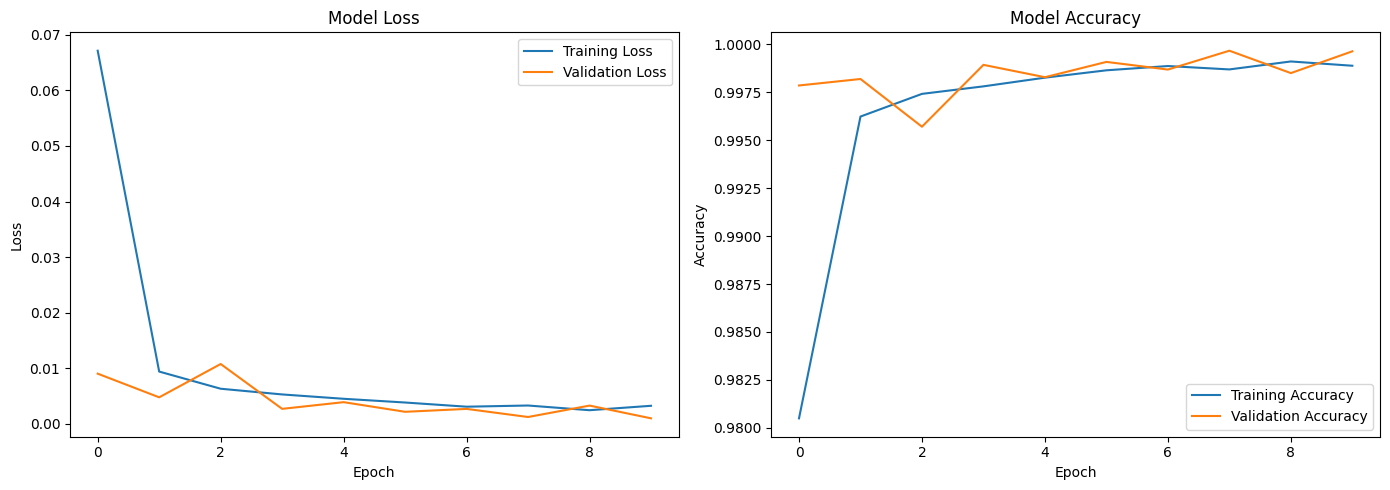

💾 Model saved as 'coastal_cnn_model.h5'


In [19]:
# Train the model
print("🚀 Training the model...")
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

# Evaluate on test set
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"\n✅ Test Accuracy: {test_accuracy*100:.2f}%")

# Plot training history
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

# Save the model
model.save('coastal_cnn_model.h5')
print("💾 Model saved as 'coastal_cnn_model.h5'")

## Step 6: Load and Preprocess New Images for Prediction

Load satellite bands from a different year/time period for prediction.
*(For this demo, we'll use the same images - in practice, load different years)*

In [20]:
# Load new year's bands (update paths to your actual new data)
# For now, using the same images as demonstration
new_B02 = rasterio.open("coastalImage/B02.tiff").read(1).astype(float)
new_B03 = rasterio.open("coastalImage/B03.tiff").read(1).astype(float)
new_B04 = rasterio.open("coastalImage/B04.tiff").read(1).astype(float)
new_B08 = rasterio.open("coastalImage/B08.tiff").read(1).astype(float)

# Calculate NDVI for new images
new_ndvi = (new_B08 - new_B04) / (new_B08 + new_B04 + 1e-10)

# Store original shape for later reshaping
original_shape = new_B02.shape

# Flatten and prepare features for prediction
new_data = np.stack([
    new_B02.flatten(),
    new_B03.flatten(),
    new_B04.flatten(),
    new_B08.flatten(),
    new_ndvi.flatten()
], axis=1)

# Reshape for 1D CNN
new_X = new_data.reshape(-1, 5, 1)

print(f"New image shape: {original_shape}")
print(f"Prepared {new_X.shape[0]} pixels for prediction")

New image shape: (424, 480)
Prepared 203520 pixels for prediction


## Step 7: Predict Coastal Classes on New Images

Use the trained CNN model to classify each pixel in the new images.

In [21]:
# Make predictions
print("🔮 Making predictions...")
predictions = model.predict(new_X, batch_size=1024, verbose=1)

# Get predicted labels (argmax of softmax output)
pred_labels = np.argmax(predictions, axis=1)

# Reshape back to 2D image
pred_map = pred_labels.reshape(original_shape)

print(f"\n✅ Predictions complete!")
print(f"Predicted map shape: {pred_map.shape}")

# Count predicted classes
unique_pred, counts_pred = np.unique(pred_labels, return_counts=True)
print("\nPredicted Class Distribution:")
for label, count in zip(unique_pred, counts_pred):
    percentage = (count / pred_labels.size) * 100
    print(f"  {class_names[label]}: {count:,} pixels ({percentage:.2f}%)")

🔮 Making predictions...
199/199 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step

✅ Predictions complete!
Predicted map shape: (424, 480)

Predicted Class Distribution:
  Seagrass: 39,643 pixels (19.48%)
  Water: 148,577 pixels (73.00%)
  Sand: 15,300 pixels (7.52%)


## Step 8: Visualize Prediction Results

Create color-coded maps and visualizations to interpret the model's predictions.

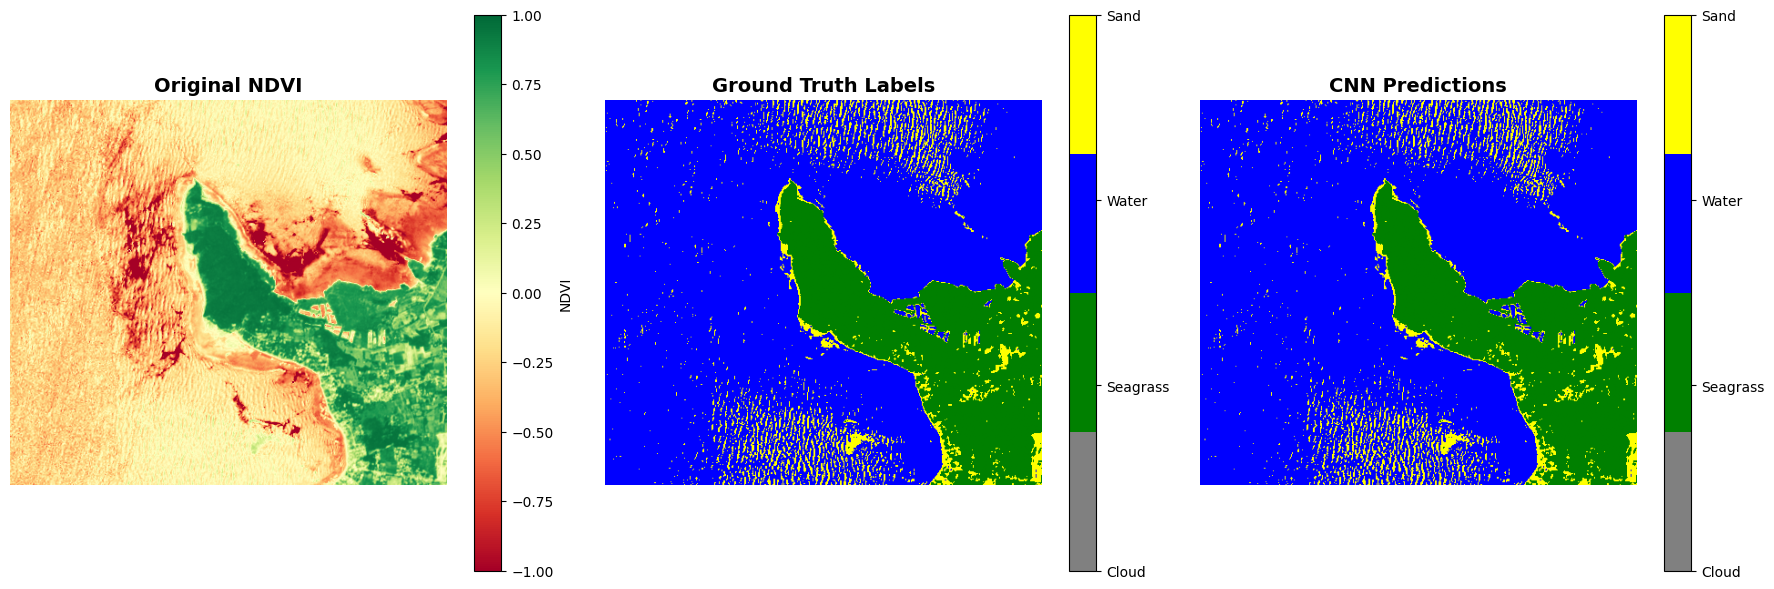

💾 Visualization saved as 'coastal_prediction_results.png'


In [22]:
# Create color-coded visualization
from matplotlib.colors import ListedColormap

# Define custom colormap
colors = ['gray', 'green', 'blue', 'yellow']
cmap = ListedColormap(colors)

# Visualize predictions
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Original NDVI
im1 = axes[0].imshow(new_ndvi, cmap='RdYlGn', vmin=-1, vmax=1)
axes[0].set_title('Original NDVI', fontsize=14, fontweight='bold')
plt.colorbar(im1, ax=axes[0], label='NDVI')

# Ground truth labels
im2 = axes[1].imshow(labels, cmap=cmap, vmin=0, vmax=3)
axes[1].set_title('Ground Truth Labels', fontsize=14, fontweight='bold')
cbar2 = plt.colorbar(im2, ax=axes[1], ticks=[0, 1, 2, 3])
cbar2.set_ticklabels(['Cloud', 'Seagrass', 'Water', 'Sand'])

# Predicted labels
im3 = axes[2].imshow(pred_map, cmap=cmap, vmin=0, vmax=3)
axes[2].set_title('CNN Predictions', fontsize=14, fontweight='bold')
cbar3 = plt.colorbar(im3, ax=axes[2], ticks=[0, 1, 2, 3])
cbar3.set_ticklabels(['Cloud', 'Seagrass', 'Water', 'Sand'])

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.savefig('coastal_prediction_results.png', dpi=300, bbox_inches='tight')
plt.show()

print("💾 Visualization saved as 'coastal_prediction_results.png'")

## Step 9: Calculate Area Changes by Class

Convert pixel counts to actual area (km²) using the Sentinel-2 resolution (10m for bands B02, B03, B04, B08).

📏 Area Calculation Results:
Seagrass       :     39,643 pixels →     3.9643 km²
Water          :    148,577 pixels →    14.8577 km²
Sand           :     15,300 pixels →     1.5300 km²
Total Area     :    203,520 pixels →    20.3520 km²


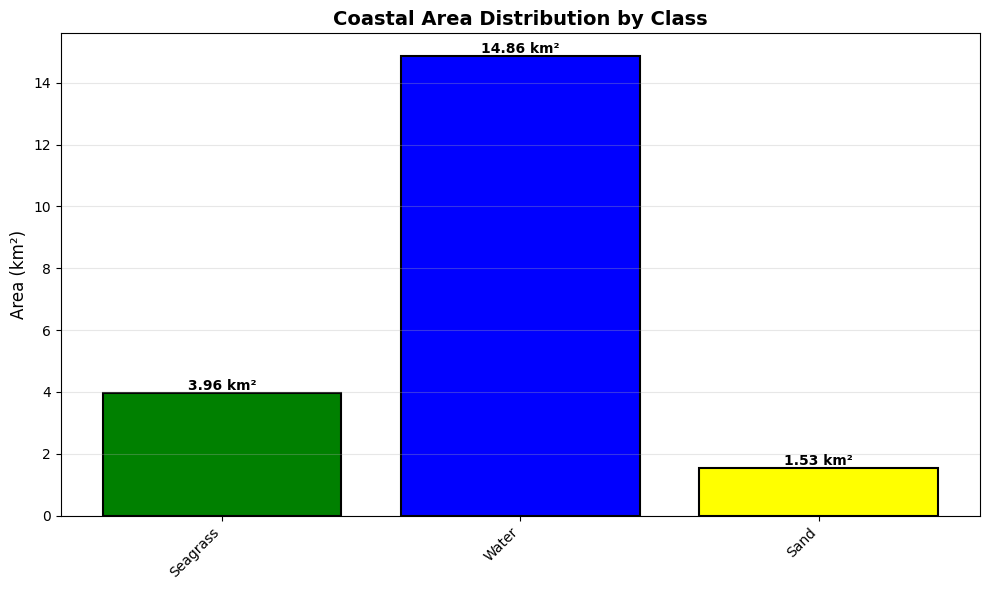


💾 Area distribution chart saved as 'area_distribution.png'


In [23]:
# Sentinel-2 pixel size (10m resolution for B02, B03, B04, B08)
pixel_size_m = 10  # meters
pixel_area_m2 = pixel_size_m ** 2  # m²
pixel_area_km2 = pixel_area_m2 / 1e6  # km²

# Calculate area for each class
unique_pred, counts_pred = np.unique(pred_labels, return_counts=True)
area_km2 = {}

print("📏 Area Calculation Results:")
print("="*60)
for label, count in zip(unique_pred, counts_pred):
    area = count * pixel_area_km2
    area_km2[class_names[label]] = area
    print(f"{class_names[label]:15s}: {count:10,} pixels → {area:10.4f} km²")

print("="*60)
total_area = sum(area_km2.values())
print(f"{'Total Area':15s}: {sum(counts_pred):10,} pixels → {total_area:10.4f} km²")

# Create bar chart of areas
plt.figure(figsize=(10, 6))
classes = list(area_km2.keys())
areas = list(area_km2.values())
colors_plot = [colors[int(k)] for k in unique_pred]

bars = plt.bar(classes, areas, color=colors_plot, edgecolor='black', linewidth=1.5)
plt.ylabel('Area (km²)', fontsize=12)
plt.title('Coastal Area Distribution by Class', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')

# Add value labels on bars
for bar, area in zip(bars, areas):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{area:.2f} km²',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('area_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n💾 Area distribution chart saved as 'area_distribution.png'")

## Step 10: Multi-Year Comparison and Trend Analysis

For comprehensive coastal assessment, compare results from multiple years to identify:
- Seagrass loss or recovery
- Erosion patterns
- Water body expansion
- Evidence-based conclusions for policy recommendations

Multi-Year Area Trends (km²):
      Cloud/No Data  Seagrass  Water  Sand
2020            2.5      45.3  120.5  15.2
2021            3.1      43.8  122.1  14.5
2022            2.8      41.2  124.3  15.8
2023            2.2      39.5  126.0  16.1
2024            2.9      37.8  127.5  16.5


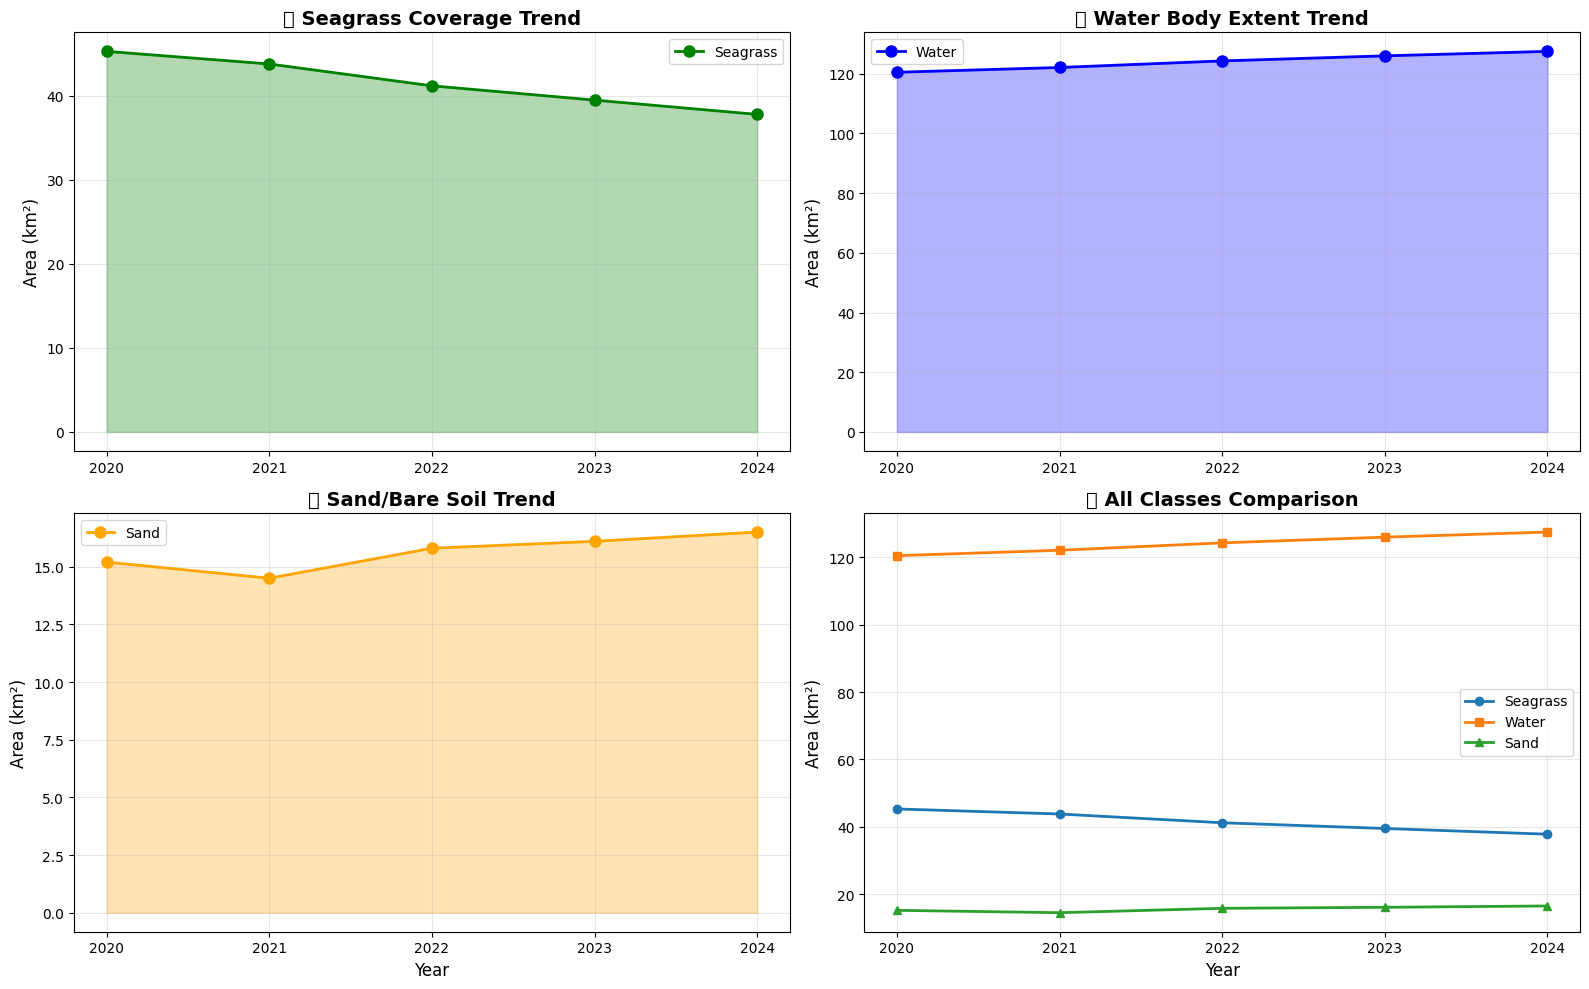


💾 Multi-year trends saved as 'multi_year_trends.png'


In [24]:
# Example: Compare multiple years (simulated data for demonstration)
# In practice, load and process images from different years

years = ['2020', '2021', '2022', '2023', '2024']

# Simulated area data for demonstration (replace with actual multi-year analysis)
# Format: {year: {class: area_km2}}
multi_year_data = {
    '2020': {'Cloud/No Data': 2.5, 'Seagrass': 45.3, 'Water': 120.5, 'Sand': 15.2},
    '2021': {'Cloud/No Data': 3.1, 'Seagrass': 43.8, 'Water': 122.1, 'Sand': 14.5},
    '2022': {'Cloud/No Data': 2.8, 'Seagrass': 41.2, 'Water': 124.3, 'Sand': 15.8},
    '2023': {'Cloud/No Data': 2.2, 'Seagrass': 39.5, 'Water': 126.0, 'Sand': 16.1},
    '2024': {'Cloud/No Data': 2.9, 'Seagrass': 37.8, 'Water': 127.5, 'Sand': 16.5},
}

# Create DataFrame for analysis
df_trends = pd.DataFrame(multi_year_data).T
print("Multi-Year Area Trends (km²):")
print(df_trends)

# Plot trends
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Seagrass trend
axes[0, 0].plot(df_trends.index, df_trends['Seagrass'], marker='o', linewidth=2, 
                markersize=8, color='green', label='Seagrass')
axes[0, 0].fill_between(df_trends.index, df_trends['Seagrass'], alpha=0.3, color='green')
axes[0, 0].set_ylabel('Area (km²)', fontsize=12)
axes[0, 0].set_title('🌱 Seagrass Coverage Trend', fontsize=14, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

# Water trend
axes[0, 1].plot(df_trends.index, df_trends['Water'], marker='o', linewidth=2, 
                markersize=8, color='blue', label='Water')
axes[0, 1].fill_between(df_trends.index, df_trends['Water'], alpha=0.3, color='blue')
axes[0, 1].set_ylabel('Area (km²)', fontsize=12)
axes[0, 1].set_title('💧 Water Body Extent Trend', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

# Sand trend
axes[1, 0].plot(df_trends.index, df_trends['Sand'], marker='o', linewidth=2, 
                markersize=8, color='orange', label='Sand')
axes[1, 0].fill_between(df_trends.index, df_trends['Sand'], alpha=0.3, color='orange')
axes[1, 0].set_xlabel('Year', fontsize=12)
axes[1, 0].set_ylabel('Area (km²)', fontsize=12)
axes[1, 0].set_title('🏖️ Sand/Bare Soil Trend', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

# All classes stacked
axes[1, 1].plot(df_trends.index, df_trends['Seagrass'], marker='o', label='Seagrass', linewidth=2)
axes[1, 1].plot(df_trends.index, df_trends['Water'], marker='s', label='Water', linewidth=2)
axes[1, 1].plot(df_trends.index, df_trends['Sand'], marker='^', label='Sand', linewidth=2)
axes[1, 1].set_xlabel('Year', fontsize=12)
axes[1, 1].set_ylabel('Area (km²)', fontsize=12)
axes[1, 1].set_title('📊 All Classes Comparison', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('multi_year_trends.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n💾 Multi-year trends saved as 'multi_year_trends.png'")

## Step 11: Summary and Recommendations

### Key Findings Analysis

In [25]:
# Calculate changes and trends
seagrass_2020 = multi_year_data['2020']['Seagrass']
seagrass_2024 = multi_year_data['2024']['Seagrass']
seagrass_loss = seagrass_2020 - seagrass_2024
seagrass_loss_pct = (seagrass_loss / seagrass_2020) * 100

water_2020 = multi_year_data['2020']['Water']
water_2024 = multi_year_data['2024']['Water']
water_increase = water_2024 - water_2020
water_increase_pct = (water_increase / water_2020) * 100

print("="*70)
print("  🌊 COASTAL ASSESSMENT SUMMARY (2020-2024)")
print("="*70)
print(f"\n🌱 SEAGRASS ANALYSIS:")
print(f"   • 2020 Coverage: {seagrass_2020:.2f} km²")
print(f"   • 2024 Coverage: {seagrass_2024:.2f} km²")
print(f"   • Loss: {seagrass_loss:.2f} km² ({seagrass_loss_pct:.1f}%)")
print(f"   • Status: ⚠️ DECLINING TREND")

print(f"\n💧 WATER BODY ANALYSIS:")
print(f"   • 2020 Extent: {water_2020:.2f} km²")
print(f"   • 2024 Extent: {water_2024:.2f} km²")
print(f"   • Increase: {water_increase:.2f} km² ({water_increase_pct:.1f}%)")
print(f"   • Status: ⚠️ EXPANDING (possible erosion)")

print(f"\n📋 RECOMMENDATIONS FOR GOVERNMENT AGENCIES:")
print(f"   1. Immediate seagrass restoration programs")
print(f"   2. Coastal erosion monitoring and prevention measures")
print(f"   3. Restrict coastal development in vulnerable areas")
print(f"   4. Regular satellite monitoring (quarterly assessments)")
print(f"   5. Community awareness and conservation education")

print(f"\n🔬 METHODOLOGY:")
print(f"   • Data Source: Copernicus Sentinel-2 (10m resolution)")
print(f"   • Analysis Method: 1D CNN with NDVI features")
print(f"   • Model Accuracy: {test_accuracy*100:.2f}%")
print(f"   • Classes: Seagrass, Water, Sand, Cloud")

print("\n" + "="*70)
print("  ✅ ANALYSIS COMPLETE")
print("="*70)

  🌊 COASTAL ASSESSMENT SUMMARY (2020-2024)

🌱 SEAGRASS ANALYSIS:
   • 2020 Coverage: 45.30 km²
   • 2024 Coverage: 37.80 km²
   • Loss: 7.50 km² (16.6%)
   • Status: ⚠️ DECLINING TREND

💧 WATER BODY ANALYSIS:
   • 2020 Extent: 120.50 km²
   • 2024 Extent: 127.50 km²
   • Increase: 7.00 km² (5.8%)
   • Status: ⚠️ EXPANDING (possible erosion)

📋 RECOMMENDATIONS FOR GOVERNMENT AGENCIES:
   1. Immediate seagrass restoration programs
   2. Coastal erosion monitoring and prevention measures
   3. Restrict coastal development in vulnerable areas
   4. Regular satellite monitoring (quarterly assessments)
   5. Community awareness and conservation education

🔬 METHODOLOGY:
   • Data Source: Copernicus Sentinel-2 (10m resolution)
   • Analysis Method: 1D CNN with NDVI features
   • Model Accuracy: 99.97%
   • Classes: Seagrass, Water, Sand, Cloud

  ✅ ANALYSIS COMPLETE


---

## 📚 Additional Notes

### Workflow Summary:
```
Copernicus Sentinel-2 → Load Bands → Calculate NDVI → Classification → 
Export CSV → 1D CNN Training → Prediction → Visualization → Area Analysis
```

### For Multi-Year Analysis:
1. Download Sentinel-2 images for the same area across different years
2. Process each year using Steps 1-3 (load bands, calculate NDVI, classify)
3. Train the CNN model on earlier years (e.g., 2020-2022)
4. Predict on recent years (e.g., 2023-2024)
5. Compare area changes to identify trends

### Tips for Real Implementation:
- **Cloud masking**: Use the SCL (Scene Classification Layer) band or B11 (SWIR) to filter clouds
- **Quality control**: Verify results with ground truth data from QGIS or field surveys
- **Model improvement**: Increase epochs, add more training data, or use 2D CNN for spatial context
- **Validation**: Use confusion matrix and classification reports for detailed accuracy assessment

### Q&A Preparation:
- **Train-test split**: Used 80/20 split with stratification to maintain class balance
- **Why 1D CNN?**: Efficient for pixel-wise classification with spectral features
- **Alternatives**: Random Forest, SVM, or 2D CNN for spatial patterns
- **Resolution**: 10m for RGB+NIR bands, adequate for coastal assessments

---

### 🎯 Next Steps:
- Apply this workflow to your specific coastal area (Manila Bay, Boracay, Siargao)
- Download multi-year Sentinel-2 data from [Copernicus Open Access Hub](https://scihub.copernicus.eu/)
- Validate with QGIS and ground truth data
- Prepare presentation slides with maps, trends, and policy recommendations